# Mission Partie 1 : Modélisation Supervisée

Ce notebook présente les phases de feature engineering, de préparation des variables, d'entraînement de modèles de régression et d'optimisation des hyperparamètres.


### Import des modules 


In [1]:
# Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

# Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

## 1. Feature Engineering

Nous construisons de nouvelles variables basées sur l'expertise métier afin de fournir un meilleur signal prédictif à nos modèles (âge du bâtiment, surface moyenne par étage, spécialisation de l'usage).


A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 


In [2]:
# Cellule ajoutée automatiquement: rendre le notebook autonome en chargeant le CSV
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
PROJECT_ROOT = '.'
DATA_PATH = './2016_Building_Energy_Benchmarking.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = os.path.join('Projet-6-Anticipez-les-besoins-en-consommation-de-b-timents-main','2016_Building_Energy_Benchmarking.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f'CSV introuvable: {DATA_PATH}')
building_consumption = pd.read_csv(DATA_PATH, low_memory=False)
print('CSV chargé:', DATA_PATH, '->', building_consumption.shape)
MODEL_DIR = './model'
import pathlib
pathlib.Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)


CSV chargé: ./2016_Building_Energy_Benchmarking.csv -> (3376, 46)


In [3]:
df = building_consumption.copy()

# Filtrage pour exclure les bâtiments résidentiels (Multifamily)
non_residential_mask = ~df['BuildingType'].str.contains('Multifamily', case=False, na=False)
df = df[non_residential_mask].copy()
print(f'Shape après retrait des Multifamily : {df.shape}')

# Calcul de l'âge du bâtiment en 2016
df['BuildingAge'] = df['DataYear'] - df['YearBuilt']
print("BuildingAge créée")
display(df[['DataYear', 'YearBuilt', 'BuildingAge']].head())

# Estimation de la surface moyenne par étage
mask_valid_floors = df['NumberofFloors'].notna() & (df['NumberofFloors'] > 0)
df['SurfaceParEtage'] = np.nan
df.loc[mask_valid_floors, 'SurfaceParEtage'] = (
    df.loc[mask_valid_floors, 'PropertyGFATotal'] / df.loc[mask_valid_floors, 'NumberofFloors']
)
print("SurfaceParEtage créée")

# Calcul de la proportion occupée par l'usage principal
mask_valid_area = df['PropertyGFATotal'] > 0
df['RatioLargestUse'] = np.nan
df.loc[mask_valid_area, 'RatioLargestUse'] = (
    df.loc[mask_valid_area, 'LargestPropertyUseTypeGFA'] / df.loc[mask_valid_area, 'PropertyGFATotal']
)
print("RatioLargestUse créée")

# Regroupement thématique des usages pour réduire la cardinalité
mapping = {
    "Small- and Mid-Sized Office": "Office",
    "Large Office": "Office",
    "Medical Office": "Office",
    "Office": "Office",
    "K-12 School": "Education",
    "University": "Education",
    "Retail Store": "Retail & Food",
    "Supermarket / Grocery Store": "Retail & Food",
    "Restaurant": "Retail & Food",
    "Warehouse": "Industrial & Storage",
    "Distribution Center": "Industrial & Storage",
    "Refrigerated Warehouse": "Industrial & Storage",
    "Self-Storage Facility": "Industrial & Storage",
    "Laboratory": "Industrial & Storage",
    "Hotel": "Hospitality",
    "Hospital": "Healthcare",
    "Worship Facility": "Public / Institutional",
    "Mixed Use Property": "Mixed Use",
    "Other": "Other",
    # Types résidentiels résiduels à supprimer (dans les NonResidential mal classés)
    # ces types sont en fait résidentiels malgré le BuildingType
    "Residence Hall": "Delete",
    "Senior Care Community": "Delete",
}

df["PropertyCategory"] = df["PrimaryPropertyType"].map(mapping).fillna("Other")
print("\nRépartition PropertyCategory :")
print(df["PropertyCategory"].value_counts())

# Suppression des lignes résidentielles résiduelles
# PropertyCategory == 'Delete' = types résidentiels résiduels à exclure
n_delete = (df['PropertyCategory'] == 'Delete').sum()
df = df[df['PropertyCategory'] != 'Delete'].copy()
print(f'\nLignes résidentielles résiduelles supprimées : {n_delete}')
print(f'Shape après suppression : {df.shape}')

# Remplacement des valeurs manquantes pour le deuxième usage par 0
# Un NaN signifie l'absence de 2e usage => on remplace par 0
df['SecondLargestPropertyUseTypeGFA'] = df['SecondLargestPropertyUseTypeGFA'].fillna(0.0)

print(f'\nShape finale après feature engineering : {df.shape}')

Shape après retrait des Multifamily : (1668, 46)
BuildingAge créée


,DataYear,YearBuilt,BuildingAge
0,2016,1927,89
1,2016,1996,20
2,2016,1969,47
3,2016,1926,90
4,2016,1980,36


SurfaceParEtage créée
RatioLargestUse créée

Répartition PropertyCategory :
PropertyCategory
Office                    507
Industrial & Storage      290
Other                     253
Education                 163
Retail & Food             143
Mixed Use                 114
Hospitality                76
Public / Institutional     71
Delete                     41
Healthcare                 10
Name: count, dtype: int64

Lignes résidentielles résiduelles supprimées : 41
Shape après suppression : (1627, 50)

Shape finale après feature engineering : (1627, 50)


## 2. Préparation des variables et Gestion des Outliers

Nous appliquons la méthode IQR (Interquartile Range) par catégorie d'usage de bâtiment pour écarter les valeurs aberrantes sans éliminer d'exemples valides. Nous étudions également les corrélations linéaires.


A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.


Features numériques : 10
Features dummy : 8 -> ['PropertyCategory_Healthcare', 'PropertyCategory_Hospitality', 'PropertyCategory_Industrial & Storage', 'PropertyCategory_Mixed Use', 'PropertyCategory_Office', 'PropertyCategory_Other', 'PropertyCategory_Public / Institutional', 'PropertyCategory_Retail & Food']

Dataset modélisation : (1627, 20)

Résumé suppression outliers IQR par catégorie :


,category,n,lo,hi,removed,removed_pct
5,Office,507,0,2.127660e+07,50,9.9
6,Other,253,0,1.783597e+07,30,11.9
3,Industrial & Storage,290,0,4.939984e+06,26,9.0
0,Education,163,0,7.476770e+06,22,13.5
4,Mixed Use,114,0,1.593425e+07,16,14.0
2,Hospitality,76,0,2.485791e+07,10,13.2
7,Public / Institutional,71,0,2.785217e+06,4,5.6
8,Retail & Food,143,0,1.993269e+07,3,2.1
1,Healthcare,10,0,4.878831e+08,0,0.0



Outliers supprimés par catégorie :
Shape après nettoyage : (1466, 20)


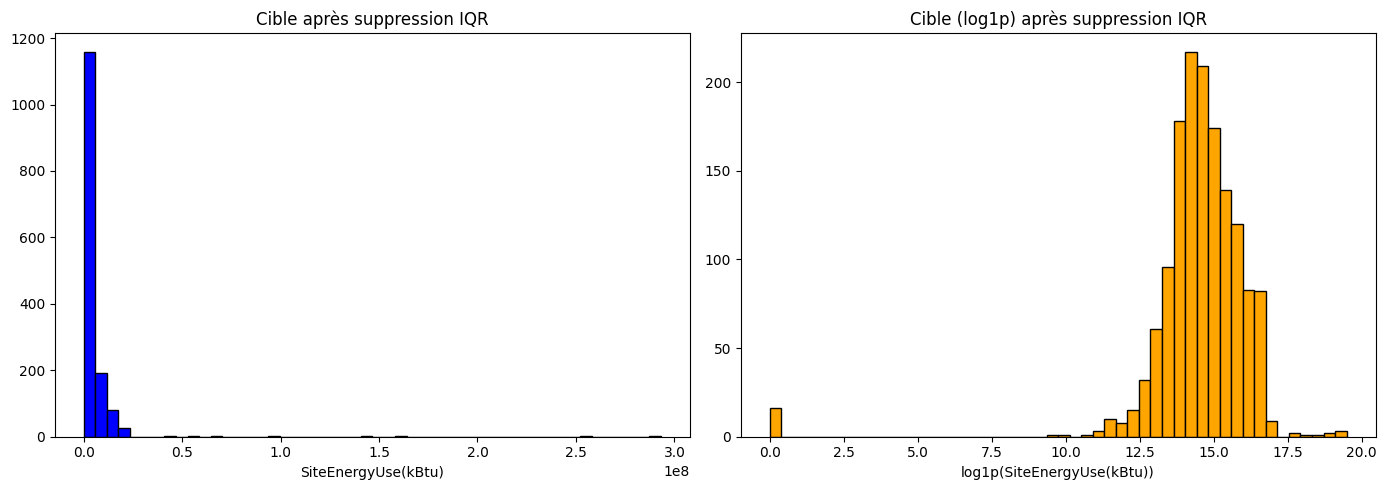

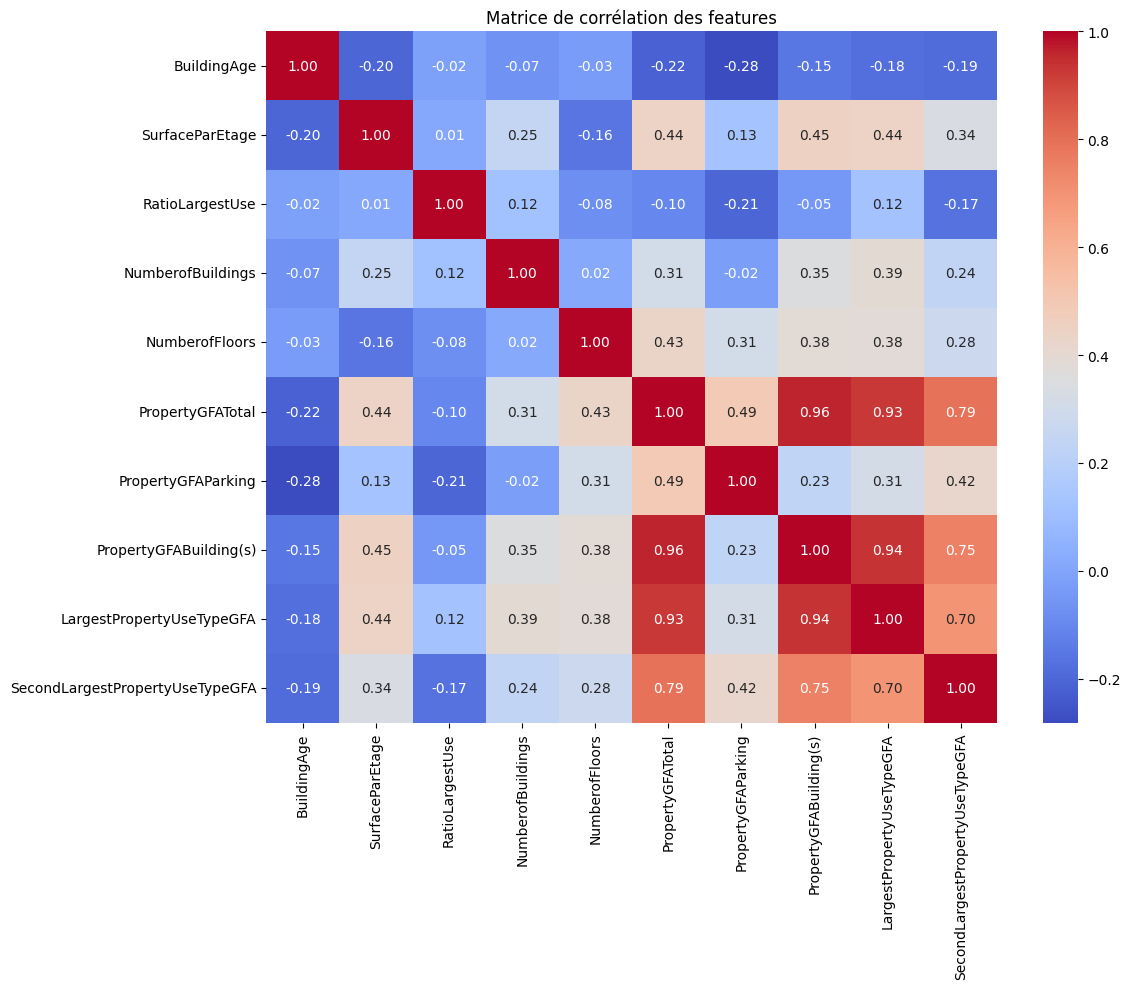

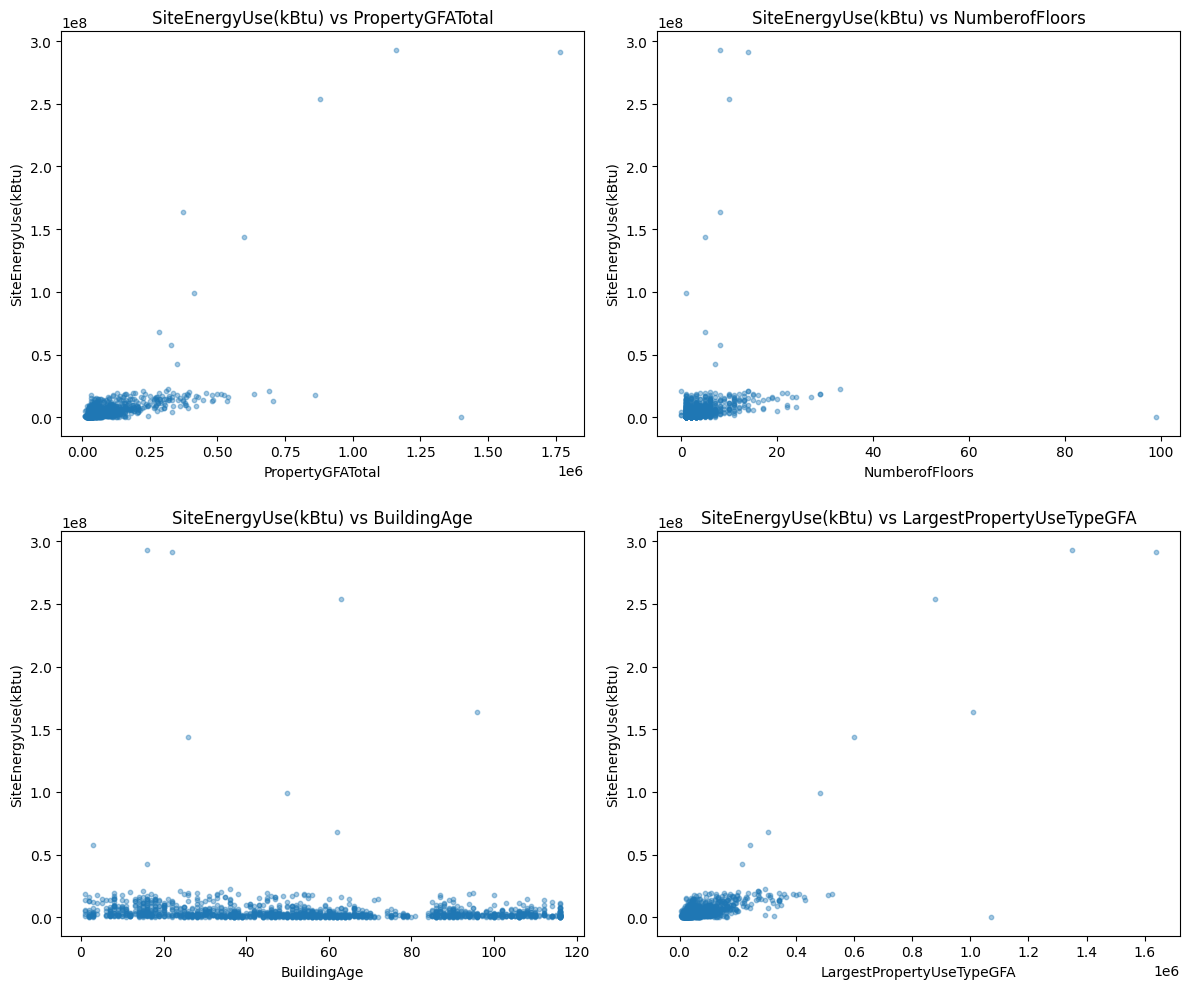

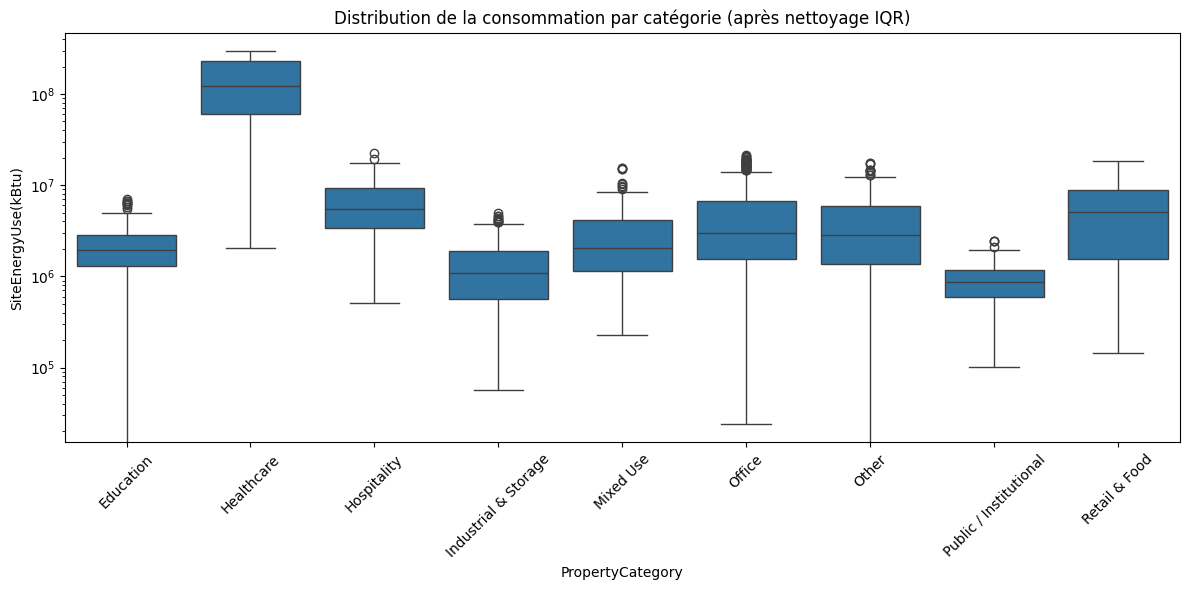


X : (1457, 18) | y : (1457,)
NaN X : 0 | NaN y : 0


In [4]:
# Sélection des variables explicatives finales
features_num = [
    "BuildingAge",
    "SurfaceParEtage",
    "RatioLargestUse",
    "NumberofBuildings",
    "NumberofFloors",
    "PropertyGFATotal",
    "PropertyGFAParking",
    "PropertyGFABuilding(s)",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
]
feature_cat = "PropertyCategory"
target = "SiteEnergyUse(kBtu)"

# Encodage One-Hot de la catégorie d'usage
ohe = pd.get_dummies(df[feature_cat], prefix='PropertyCategory', drop_first=True).astype(np.int8)
df = pd.concat([df, ohe], axis=1)


dummy_feats = list(ohe.columns)
all_feats = features_num + dummy_feats
print(f"Features numériques : {len(features_num)}")
print(f"Features dummy : {len(dummy_feats)} -> {dummy_feats}")

# Création du sous-ensemble de modélisation
ml_df = df[all_feats + [target, feature_cat]].copy()


print(f"\nDataset modélisation : {ml_df.shape}")
# Détection des outliers par catégorie avec la méthode IQR
def iqr_bounds(s, k=1.5):
    """Retourne (borne_basse, borne_haute) selon la méthode IQR."""
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    return max(0, Q1 - k * IQR), Q3 + k * IQR

min_n = 8  # taille min pour appliquer IQR
clean_frames = []
records = []

for cat, sub in ml_df.groupby(feature_cat):
    n = len(sub)
    if n < min_n:
        clean_frames.append(sub)
        records.append({"category": cat, "n": n, "removed": 0, "note": "skip (n<min_n)"})
        continue
    lo, hi = iqr_bounds(sub[target], k=1.5)
    mask_out = (sub[target] < lo) | (sub[target] > hi)
    n_out = int(mask_out.sum())
    clean_frames.append(sub.loc[~mask_out])
    records.append({"category": cat, "n": n, "lo": lo, "hi": hi,
                     "removed": n_out, "removed_pct": round(n_out/n*100, 1)})

ml_df = pd.concat(clean_frames, ignore_index=True)
summary_cat = pd.DataFrame(records).sort_values("removed", ascending=False)
print("\nRésumé suppression outliers IQR par catégorie :")
display(summary_cat)
print("\nOutliers supprimés par catégorie :")

print(f"Shape après nettoyage : {ml_df.shape}")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Distrib de la cible après nettoyage
axes[0].set_title("Cible après suppression IQR")
axes[0].hist(ml_df[target], bins=50, edgecolor='black', color='blue')
axes[0].set_xlabel(target)

axes[1].hist(np.log1p(ml_df[target]), bins=50, edgecolor='black', color='orange')
axes[1].set_title("Cible (log1p) après suppression IQR")
axes[1].set_xlabel(f"log1p({target})")
plt.tight_layout()
plt.show()

# Analyse des corrélations des variables quantitatives
# On calcule la corrélation pour repérer les features redondantes
corr_matrix = ml_df[features_num].corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice de corrélation des features")
plt.tight_layout()
plt.show()

# Relation entre la cible et les variables de surface/âge
key_features = ['PropertyGFATotal', 'NumberofFloors', 'BuildingAge', 'LargestPropertyUseTypeGFA']
# Création de la figure pour les 4 scatterplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, feat in zip(axes.flatten(), key_features):
    ax.scatter(ml_df[feat], ml_df[target], alpha=0.4, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel(target)
    ax.set_title(f"{target} vs {feat}")
plt.tight_layout()
plt.show()

# Boxplot de la consommation d'énergie par catégorie
plt.figure(figsize=(12, 6))

sns.boxplot(data=ml_df, x=feature_cat, y=target)
plt.yscale("log")
plt.title("Distribution de la consommation par catégorie (après nettoyage IQR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Application de la transformation logarithmique log1p sur la cible
# On applique log1p pour rendre la distribution plus symétrique (normalise les grands écarts)
log_col = "log1p_SiteEnergyUse_kBtu"
ml_df[log_col] = np.log1p(ml_df[target])

# Définition de la matrice X et du vecteur y

X = ml_df[all_feats].copy()
y = ml_df[log_col].copy()

# Nettoyage des NaN résiduels
mask_valid = y.notna() & (~X.isna().any(axis=1))
# On filtre X, y ET ml_df pour qu'ils aient tous le même nombre de lignes
X = X[mask_valid]
y = y[mask_valid]
ml_df = ml_df.loc[mask_valid].reset_index(drop=True)

print(f"\nX : {X.shape} | y : {y.shape}")
print(f"NaN X : {X.isna().sum().sum()} | NaN y : {y.isna().sum()}")

## 3. Entraînement et Comparaison de Modèles

Nous mettons en place un protocole robuste par validation croisée à 5 plis sur les données d'entraînement pour comparer une régression linéaire, un RandomForest et un GradientBoosting.


A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.


X_train: (1165, 18) | X_test: (292, 18)


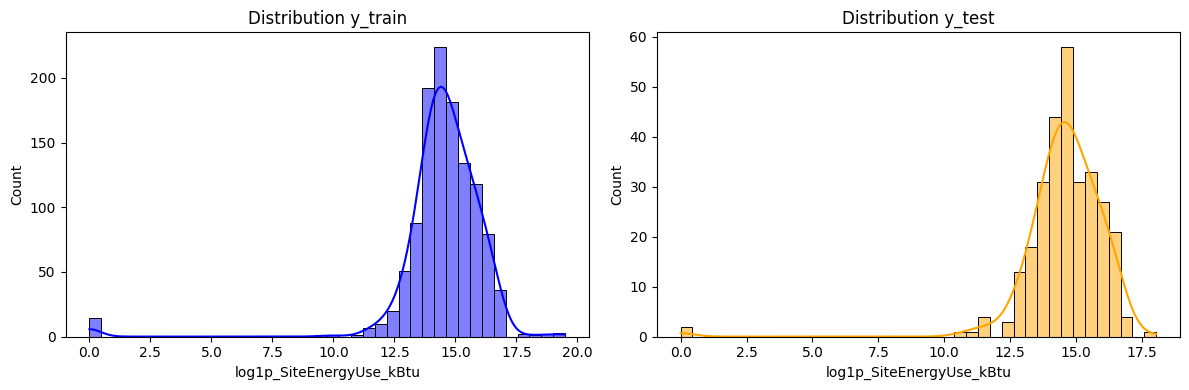

,model,train_MAE,train_RMSE,train_R2,test_MAE,test_RMSE,test_R2
1,RandomForest,0.304715,0.703494,0.869988,0.801990,1.781183,0.136416
0,LinearRegression,0.901230,1.716586,0.225222,0.928800,1.794859,0.133508
2,GradientBoosting,0.522842,0.927175,0.773274,0.802807,1.852725,0.066075



Meilleur modèle (CV) : RandomForest

=== Scores (target log1p) ===
Train -> MAE: 0.3034 | RMSE: 0.6758 | R²: 0.8802
Test  -> MAE: 0.7395 | RMSE: 1.5317 | R²: 0.1449


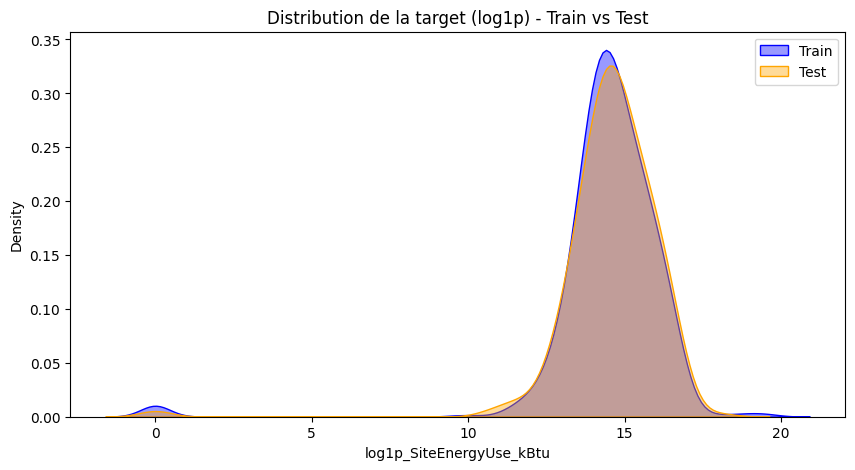

In [5]:
# Import explicite de display pour la compatibilité
try:
    from IPython.display import display
except ImportError:
    display = print

# Imports requis pour la cellule (sécurise l'exécution et calme l'analyse statique de l'IDE)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Déclarations fictives pour l'analyseur statique de l'IDE (Pyrefly)
if False:
    X, y = pd.DataFrame(), pd.Series()
    features_num = []

# Contrôle de sécurité pour s'assurer que les cellules précédentes ont été exécutées
if 'X' not in globals() or 'y' not in globals():
    raise NameError("Les variables X et y ne sont pas définies. Veuillez exécuter les cellules précédentes avant de lancer celle-ci.")

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(y_train, bins=40, kde=True, ax=axes[0], color='blue')
axes[0].set_title("Distribution y_train")
sns.histplot(y_test, bins=40, kde=True, ax=axes[1], color='orange')
axes[1].set_title("Distribution y_test")
plt.tight_layout()
plt.show()

# Variables numériques soumises au scaling

numeric_feats = [f for f in features_num if f in X_train.columns]

# Définition des pipelines de traitement et d'entraînement
pipe_lin = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipe_rf = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(random_state=42))
])

pipe_gb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42))
])

models = {
    "LinearRegression": pipe_lin,
    "RandomForest": pipe_rf,
    "GradientBoosting": pipe_gb,
}

# Évaluation des modèles par validation croisée à 5 plis

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2",
}

cv_rows = []
for name, pipe in models.items():
    cv = cross_validate(pipe, X_train, y_train,
                        scoring=scoring, cv=5, n_jobs=-1, return_train_score=True)
    cv_rows.append({
        "model": name,
        "train_MAE": -cv["train_MAE"].mean(),
        "train_RMSE": -cv["train_RMSE"].mean(),
        "train_R2": cv["train_R2"].mean(),
        "test_MAE": -cv["test_MAE"].mean(),
        "test_RMSE": -cv["test_RMSE"].mean(),
        "test_R2": cv["test_R2"].mean(),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("test_RMSE")
display(cv_df)

best_name = cv_df.iloc[0]["model"]
print(f"\nMeilleur modèle (CV) : {best_name}")
# On récupère le pipeline associé au nom du meilleur modèle
best_pipe = models[best_name]

# Entraînement final du meilleur modèle sélectionné

best_pipe.fit(X_train, y_train)

y_pred_train = best_pipe.predict(X_train)
y_pred_test = best_pipe.predict(X_test)

def compute_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

mae_tr, rmse_tr, r2_tr = compute_metrics(y_train, y_pred_train)
mae_te, rmse_te, r2_te = compute_metrics(y_test, y_pred_test)

print(f"\n=== Scores (target log1p) ===")
print(f"Train -> MAE: {mae_tr:.4f} | RMSE: {rmse_tr:.4f} | R²: {r2_tr:.4f}")
print(f"Test  -> MAE: {mae_te:.4f} | RMSE: {rmse_te:.4f} | R²: {r2_te:.4f}")

# Conversion des prédictions à l'échelle d'origine (expm1)
y_test_kbtu = np.expm1(y_test)
y_pred_kbtu = np.expm1(y_pred_test)
mae_k = mean_absolute_error(y_test_kbtu, y_pred_kbtu)
rmse_k = np.sqrt(mean_squared_error(y_test_kbtu, y_pred_kbtu))

# Contrôle visuel de la répartition Train vs Test par KDE Plot
plt.figure(figsize=(10,5))
sns.kdeplot(y_train, label="Train", fill=True, alpha=0.4, color='blue')
sns.kdeplot(y_test,  label="Test",  fill=True, alpha=0.4, color='orange')
plt.title("Distribution de la target (log1p) - Train vs Test")
plt.xlabel("log1p_SiteEnergyUse_kBtu")
plt.legend()
plt.show()


## 4. Optimisation des Hyperparamètres et Importance des Variables

Nous ajustons les hyperparamètres du modèle retenu (Random Forest) via une recherche par grille (GridSearchCV) pour améliorer la généralisation, puis analysons la contribution de chaque variable explicative.


A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 


Fitting 5 folds for each of 24 candidates, totalling 120 fits
=== GridSearch terminé ===
Meilleurs paramètres : {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Meilleur RMSE CV : 1.750414
Meilleurs params : {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 300}
RMSE CV : 1.750414

Scores TEST après tuning (log1p) :
MAE: 0.7098 | RMSE: 1.4609 | R²: 0.2221
Scores TEST (kBtu) : MAE=1,973,790 | RMSE=3,845,549
kBtu : MAE=1,973,790 | RMSE=3,845,549


C:\Users\docje\AppData\Local\Temp\ipykernel_28400\134654360.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Variable', data=df_importance, palette='magma')


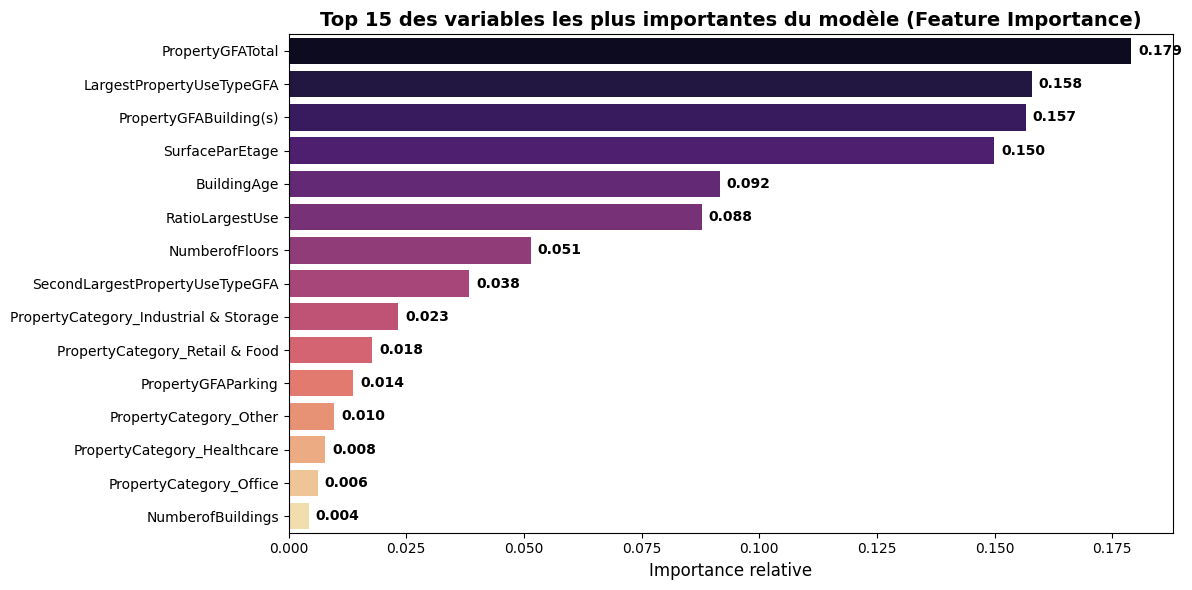

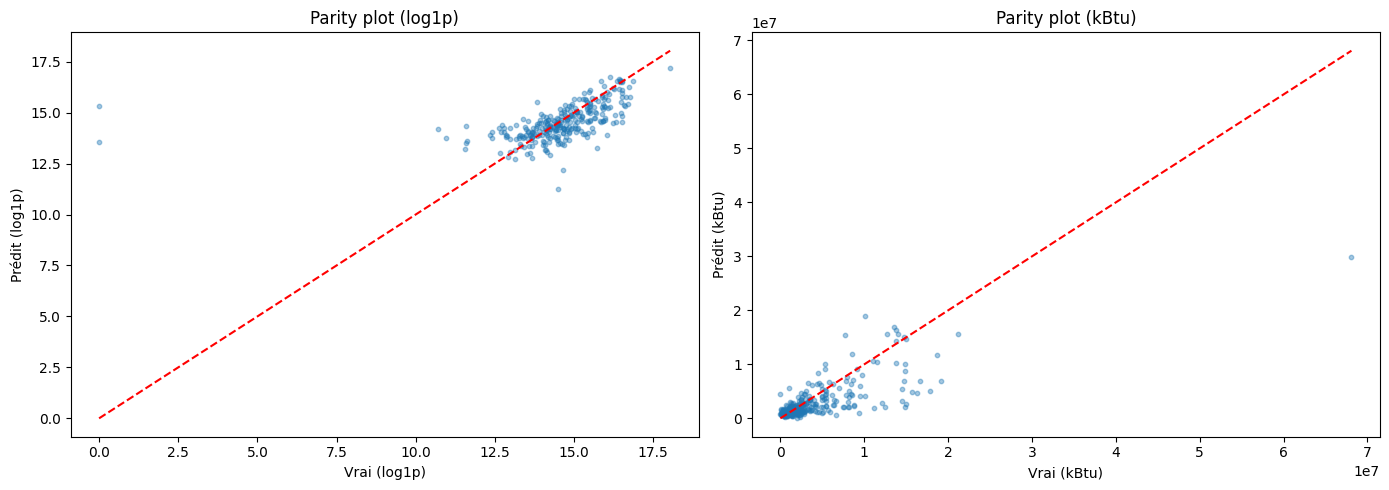

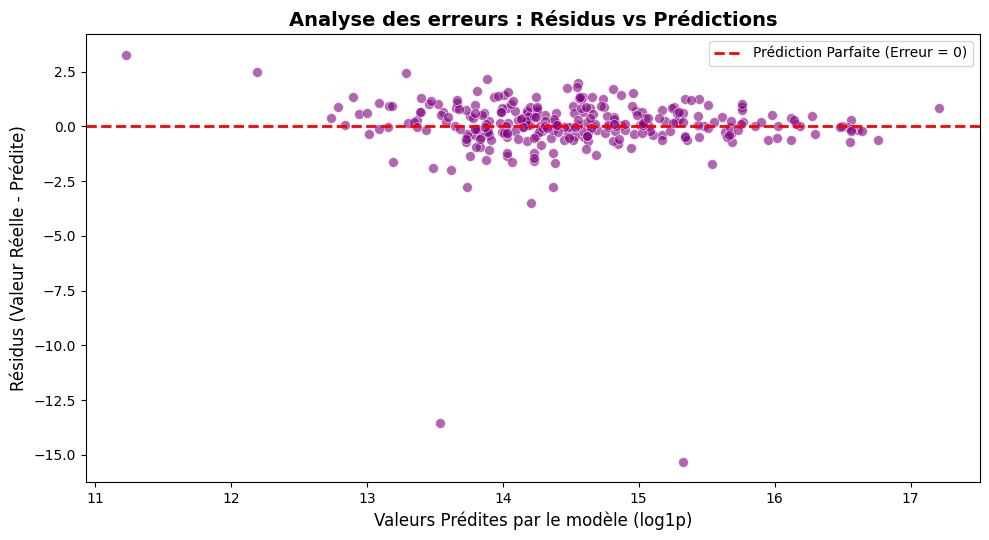


 Modèle sauvegardé : ./model/best_model.joblib
Features sauvegardées : ./model/feature_names.json
Nombre de features : 18
Features : ['BuildingAge', 'SurfaceParEtage', 'RatioLargestUse', 'NumberofBuildings', 'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking', 'PropertyGFABuilding(s)', 'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA', 'PropertyCategory_Healthcare', 'PropertyCategory_Hospitality', 'PropertyCategory_Industrial & Storage', 'PropertyCategory_Mixed Use', 'PropertyCategory_Office', 'PropertyCategory_Other', 'PropertyCategory_Public / Institutional', 'PropertyCategory_Retail & Food']


In [6]:
# Optimisation fine du modèle sélectionné par recherche par grille
if best_name == "RandomForest":
    base_pipe = pipe_rf
    param_grid = {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [2, 4],
        "model__max_features": ["sqrt"],
    }
elif best_name == "GradientBoosting":
    base_pipe = pipe_gb
    param_grid = {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [2, 4],
        "model__max_features": ["sqrt"],
    }
else:
    # Fallback : on optimise un RandomForest
    base_pipe = pipe_rf
    param_grid = {
        "model__n_estimators": [300, 600],
        "model__max_depth": [None, 20],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [2, 4],
        "model__max_features": ["sqrt"],
    }

grid = GridSearchCV(
    estimator=base_pipe,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
    verbose=1,
)
grid.fit(X_train, y_train)

best_rmse_cv = np.sqrt(-grid.best_score_)
print(f"=== GridSearch terminé ===")
print(f"Meilleurs paramètres : {grid.best_params_}")
print(f"Meilleur RMSE CV : {best_rmse_cv:.6f}")
print(f"Meilleurs params : {grid.best_params_}")
print(f"RMSE CV : {best_rmse_cv:.6f}")
best_pipe_tuned = grid.best_estimator_

# Prédictions du modèle optimisé sur le jeu de test
y_pred_test_tuned = best_pipe_tuned.predict(X_test)

mae_t = mean_absolute_error(y_test, y_pred_test_tuned)
rmse_t = np.sqrt(mean_squared_error(y_test, y_pred_test_tuned))
r2_t = r2_score(y_test, y_pred_test_tuned)

print(f"\nScores TEST après tuning (log1p) :")
print(f"MAE: {mae_t:.4f} | RMSE: {rmse_t:.4f} | R²: {r2_t:.4f}")

# Scores en kBtu
y_pred_kbtu_tuned = np.expm1(y_pred_test_tuned)
mae_k = mean_absolute_error(y_test_kbtu, y_pred_kbtu_tuned)
rmse_k = np.sqrt(mean_squared_error(y_test_kbtu, y_pred_kbtu_tuned))
print(f"Scores TEST (kBtu) : MAE={mae_k:,.0f} | RMSE={rmse_k:,.0f}")

print(f"kBtu : MAE={mae_k:,.0f} | RMSE={rmse_k:,.0f}")
tuned_model = best_pipe_tuned.named_steps["model"]


# Extraction du modèle final et des variables
final_model = best_pipe_tuned.steps[-1][1]
importances = final_model.feature_importances_
feature_names = X_train.columns

# Création du DataFrame d'importance pour les 15 premières variables
df_importance = pd.DataFrame({
    'Variable': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(15)

# Tracé du graphique en barres horizontales (Feature Importance)
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='Importance', y='Variable', data=df_importance, palette='magma')

# Ajout des coefficients textuels sur chaque barre pour plus de précision
for p in ax.patches:
    ax.annotate(f"{p.get_width():.3f}", 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=10, fontweight='bold')

plt.title("Top 15 des variables les plus importantes du modèle (Feature Importance)", fontsize=14, fontweight='bold')
plt.xlabel("Importance relative", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

# Tracé du parity plot (réel vs prédit) pour contrôle
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_test, y_pred_test_tuned, s=10, alpha=0.4)
lims = [min(y_test.min(), y_pred_test_tuned.min()), max(y_test.max(), y_pred_test_tuned.max())]
axes[0].plot(lims, lims, '--', color='red')
axes[0].set_xlabel("Vrai (log1p)")
axes[0].set_ylabel("Prédit (log1p)")
axes[0].set_title("Parity plot (log1p)")

axes[1].scatter(y_test_kbtu, y_pred_kbtu_tuned, s=10, alpha=0.4)
lims_k = [min(y_test_kbtu.min(), y_pred_kbtu_tuned.min()), max(y_test_kbtu.max(), y_pred_kbtu_tuned.max())]
axes[1].plot(lims_k, lims_k, '--', color='red')
axes[1].set_xlabel("Vrai (kBtu)")
axes[1].set_ylabel("Prédit (kBtu)")
axes[1].set_title("Parity plot (kBtu)")
plt.tight_layout()
plt.show()

# Calcul des prédictions et des résidus sur le jeu de test
y_pred = best_pipe_tuned.predict(X_test)
residus = y_test - y_pred

# Tracé du graphique des résidus (Analyse des erreurs)
plt.figure(figsize=(10, 5.5))
sns.scatterplot(x=y_pred, y=residus, alpha=0.6, color='purple', edgecolor='w', s=50)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label="Prédiction Parfaite (Erreur = 0)")
plt.title("Analyse des erreurs : Résidus vs Prédictions", fontsize=14, fontweight='bold')
plt.xlabel("Valeurs Prédites par le modèle (log1p)", fontsize=12)
plt.ylabel("Résidus (Valeur Réelle - Prédite)", fontsize=12)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Exportation du modèle entraîné et de la liste des variables
import joblib
import os
os.makedirs(MODEL_DIR, exist_ok=True)
model_path = f'{MODEL_DIR}/best_model.joblib'
joblib.dump(best_pipe_tuned, model_path)
print(f'\n Modèle sauvegardé : {model_path}')

feature_names = list(X_train.columns)
features_path = f'{MODEL_DIR}/feature_names.json'
with open(features_path, 'w', encoding='utf-8') as f:
    json.dump(feature_names, f, indent=2, ensure_ascii=False)
print(f'Features sauvegardées : {features_path}')
print(f"Nombre de features : {len(feature_names)}")
print(f"Features : {feature_names}")
